# Heavy Vehicle Failure Prediction Through Intelligent Sensor Data

## Complete Machine Learning Project Notebook

**Task:** Binary classification of APS-related failure in Scania heavy vehicles  
**Target:** `class` (`neg` = no APS-related failure, `pos` = APS-related failure)

This notebook contains the implementation, preprocessing, EDA, model training, tuning, evaluation, comparison, and final prediction demonstration required for the project review. Execute all cells from top to bottom before submission so the outputs and figures are visible.

The data contains 76,000 records, 170 sensor features, and a highly imbalanced target. Because missing a real failure can be costly, recall and F1-score are considered together with accuracy and ROC-AUC.


## 1. Import Libraries

The pipeline objects used later ensure that imputation and scaling are learned only from the training portion of the data. This prevents test-data leakage.


In [1]:
# If using Google Colab and a package is missing, run this once:
# !pip install -q scikit-learn matplotlib seaborn joblib

import os
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 2. Load the Dataset

The original combined CSV is used because it contains both sensor values and the target label. The value `na` is converted to a real missing value while loading.


In [2]:
candidate_paths = [
    Path("D:\\ML\\HEAVY VEHICLE FAILURE PREDICTION THROUGH INTELLIGENT SENSOR\\dataset\\APS_Scania_Complete_Dataset.csv"),
    Path("APS_Scania_Complete_Dataset.csv"),
    Path("/content/APS_Scania_Complete_Dataset.csv"),
    Path("/content/HEAVY VEHICLE FAILURE PREDICTION THROUGH INTELLIGENT SENSOR/dataset/APS_Scania_Complete_Dataset.csv")
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place APS_Scania_Complete_Dataset.csv in the notebook folder or update DATA_PATH.")

df = pd.read_csv(DATA_PATH, na_values=["na"])
print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())


Dataset path: D:\ML\HEAVY VEHICLE FAILURE PREDICTION THROUGH INTELLIGENT SENSOR\dataset\APS_Scania_Complete_Dataset.csv
Dataset shape: (76000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,1766008.0,1132040.0,0.0,0.0,0.0,0.0,1012.0,268.0,0.0,0.0,0.0,0.0,0.0,469014.0,4239660.0,703300.0,755876.0,0.0,5374.0,2108.0,4114.0,12348.0,615248.0,5526276.0,2378.0,4.0,0.0,0.0,2328746.0,1022304.0,415432.0,287230.0,310246.0,681504.0,1118814.0,3574.0,0.0,0.0,6700214.0,0.0,10.0,108.0,50.0,2551696.0,97518.0,947550.0,799478.0,330760.0,353400.0,299160.0,305200.0,283680.0,NaN,NaN,NaN,178540.0,76698.08,6700214.0,6700214.0,6599892.0,43566.0,68656.0,54064.0,638360.0,6167850.0,1209600.0,246244.0,2.0,96.0,0.0,5245752.00,0.0,916567.68,6.0,1924.0,0.0,0.0,0.0,118196.0,1309472.0,3247182.0,1381362.0,98822.0,11208.0,1608.0,220.0,240.0,6700214.0,NaN,10476.0,1226.0,267998.0,521832.0,428776.0,4015854.0,895240.0,26330.0,118.0,0.0,532.0,734.0,4122704.0,51288.0,0.0,532572.0,0.0,18.0,5330690.0,4732.0,1126.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62282.0,85908.0,32790.0,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,1084598.0,338544.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71510.0,772720.0,1996924.0,99560.0,0.0,7336.0,7808.0,13776.0,13086.0,1010074.0,1873902.0,14726.0,6.0,0.0,0.0,1378576.0,447166.0,199512.0,154298.0,137280.0,138668.0,165908.0,229652.0,87082.0,4708.0,3646660.0,86.0,454.0,364.0,350.0,1393352.0,49028.0,688314.0,392208.0,341420.0,359780.0,366560.0,NaN,NaN,NaN,NaN,NaN,6700.0,33057.51,3646660.0,3646660.0,3582034.0,17733.0,260120.0,115626.0,6900.0,2942850.0,1209600.0,0.0,NaN,NaN,NaN,2291079.36,0.0,643536.96,0.0,0.0,0.0,0.0,38.0,98644.0,1179502.0,1286736.0,336388.0,36294.0,5192.0,56.0,NaN,0.0,3646660.0,NaN,6160.0,796.0,164860.0,350066.0,272956.0,1837600.0,301242.0,9148.0,22.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3312.0,522.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33736.0,36946.0,5936.0,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,300796.0,153698.0,0.0,0.0,0.0,0.0,358.0,110.0,0.0,0.0,0.0,0.0,0.0,0.0,870456.0,239798.0,1450312.0,0.0,1620.0,1156.0,1228.0,34250.0,1811606.0,710672.0,34.0,0.0,0.0,0.0,790690.0,672026.0,332340.0,254892.0,189596.0,135758.0,103552.0,81666.0,46.0,0.0,2673338.0,128.0,202.0,576.0,4.0,1234132.0,28804.0,160176.0,139730.0,137160.0,13064

## 3. Dataset Description

The dataset contains anonymized sensor and operational measurements collected from Scania heavy trucks. The target indicates whether a failure is related to the Air Pressure System.


In [3]:
print("Records:", df.shape[0])
print("Columns:", df.shape[1])
print("Sensor features:", df.shape[1] - 1)
print("Target variable: class")

print("\nData types:")
display(df.dtypes.value_counts())

print("\nTarget distribution:")
display(df["class"].value_counts(dropna=False).rename_axis("class").to_frame("count"))

print("\nTarget percentage:")
display((df["class"].value_counts(normalize=True) * 100).round(2).rename("percentage").to_frame())


Records: 76000
Columns: 171
Sensor features: 170
Target variable: class

Data types:


float64    169
str          1
int64        1
Name: count, dtype: int64


Target distribution:


,count
class,
neg,74625
pos,1375



Target percentage:


,percentage
class,
neg,98.19
pos,1.81


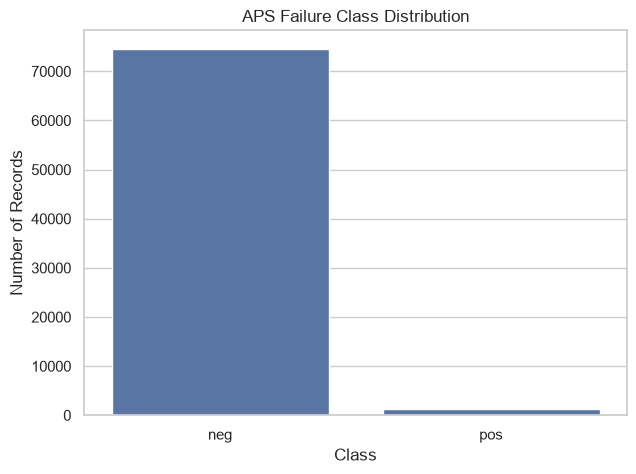

In [4]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="class", order=["neg", "pos"])
plt.title("APS Failure Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.show()


### Dataset Observation

The negative class is much larger than the positive class. This class imbalance means that a model could obtain high accuracy by mostly predicting no failure, while still missing many actual failures. Recall, F1-score, ROC-AUC, and the confusion matrix are therefore important.


## 4. Data Preprocessing

Duplicate rows are checked and removed before splitting. The target is encoded as 0 and 1. Missing values are not filled manually here; the model pipelines below learn training-only median values during fitting.


In [5]:
print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing_Percentage", ascending=False)

print("Duplicate rows after removal:", df.duplicated().sum())
print("Columns with missing values:", int((df.isna().sum() > 0).sum()))
print("Total missing cells:", int(df.isna().sum().sum()))
display(missing_summary.head(20))


Duplicate rows before removal: 0
Duplicate rows after removal: 0
Columns with missing values: 169
Total missing cells: 1078695


,Missing_Count,Missing_Percentage
br_000,62393,82.10
bq_000,61703,81.19
bp_000,60461,79.55
bo_000,58709,77.25
ab_000,58692,77.23
cr_000,58692,77.23
bn_000,55722,73.32
bm_000,50095,65.91
bl_000,34503,45.40
bk_000,29128,38.33


In [6]:
df["class"] = df["class"].map({"neg": 0, "pos": 1})

X = df.drop(columns=["class"])
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Initial dataset shape:", (76000, 171))
print("Final dataset shape after duplicate removal:", df.shape)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training class distribution:")
display(y_train.value_counts().rename_axis("class").to_frame("count"))
print("Testing class distribution:")
display(y_test.value_counts().rename_axis("class").to_frame("count"))


Initial dataset shape: (76000, 171)
Final dataset shape after duplicate removal: (76000, 171)
Training shape: (60800, 170)
Testing shape: (15200, 170)
Training class distribution:


,count
class,
0,59700
1,1100


Testing class distribution:


,count
class,
0,14925
1,275


### Leakage Prevention

The test set is held out before model fitting. Every model below uses a pipeline. The median imputer and scaler are fitted on training data only and then applied to validation or test data. This prevents information from the test set entering the training process.


## 5. Exploratory Data Analysis

The following plots inspect missingness, distributions, descriptive statistics, and correlations. Sensor outliers are retained because an extreme reading may represent an abnormal operating condition rather than an invalid value.


In [7]:
display(X.describe().T)


,count,mean,std,min,25%,50%,75%,max
aa_000,76000.0,6.115976e+04,2.647366e+05,0.0,860.0,30813.0,48840.0,4.294967e+07
ab_000,17308.0,7.255604e-01,3.311913e+00,0.0,0.0,0.0,0.0,2.040000e+02
ac_000,71739.0,3.564398e+08,7.952530e+08,0.0,16.0,154.0,970.0,2.130707e+09
ad_000,57158.0,1.506300e+05,3.590593e+07,0.0,24.0,128.0,430.0,8.584298e+09
ae_000,72810.0,6.736959e+00,1.534465e+02,0.0,0.0,0.0,0.0,2.105000e+04
...,...,...,...,...,...,...,...,...
ee_007,75137.0,3.475611e+05,1.707593e+06,0.0,112.0,41260.0,168046.0,1.195801e+08
ee_008,75137.0,1.398968e+05,4.692327e+05,0.0,0.0,3862.0,139500.0,1.926740e+07
ee_009,75137.0,8.424984e+03,4.875440e+04,0.0,0.0,0.0,2000.0,4.570398e+06
ef_000,72514.0,8.519734e-02,4.179600e+00,0.0,0.0,0.0,0.0,4.820000e+02


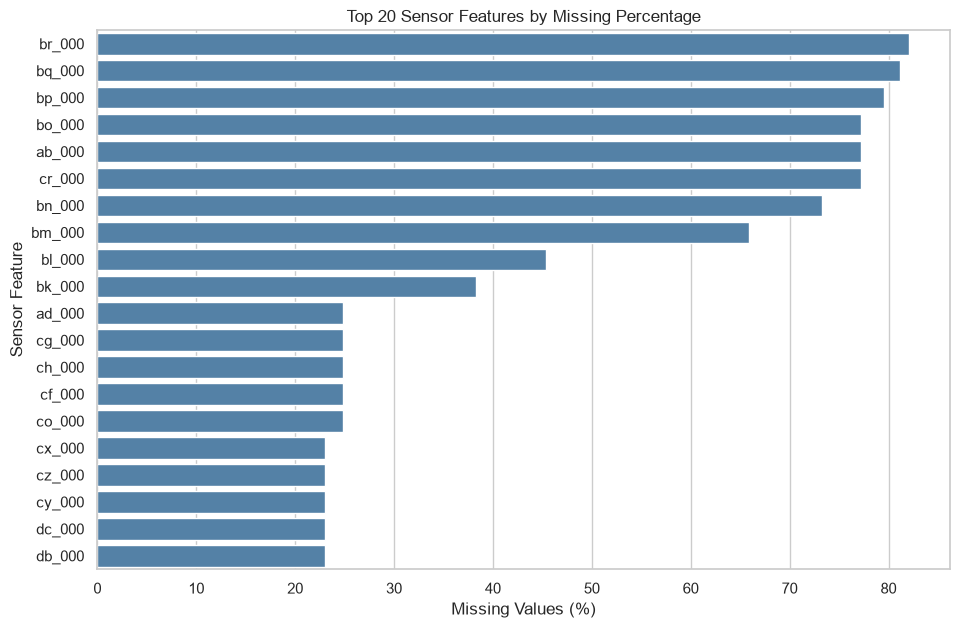

In [8]:
top_missing = missing_summary.drop(index="class", errors="ignore").head(20)
plt.figure(figsize=(11, 7))
sns.barplot(x=top_missing["Missing_Percentage"], y=top_missing.index, color="steelblue")
plt.title("Top 20 Sensor Features by Missing Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Sensor Feature")
plt.show()


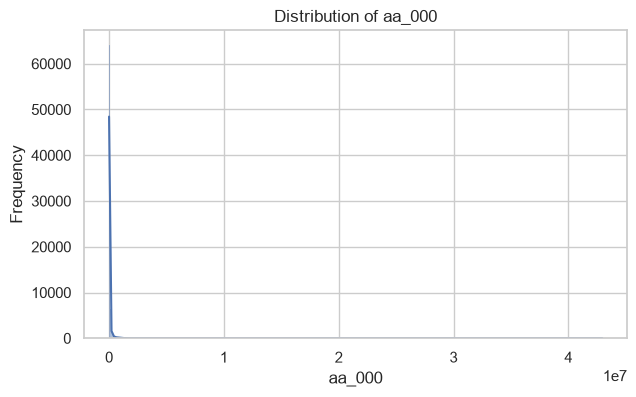

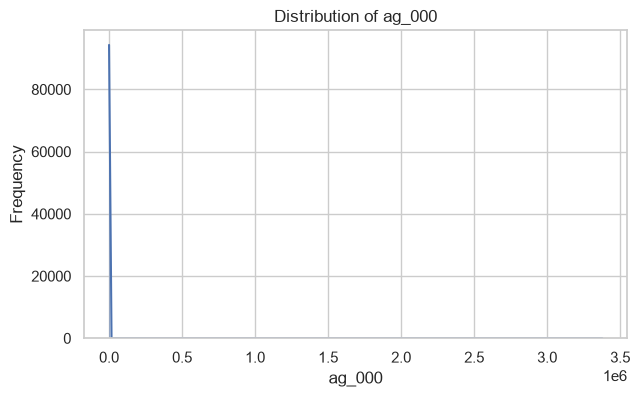

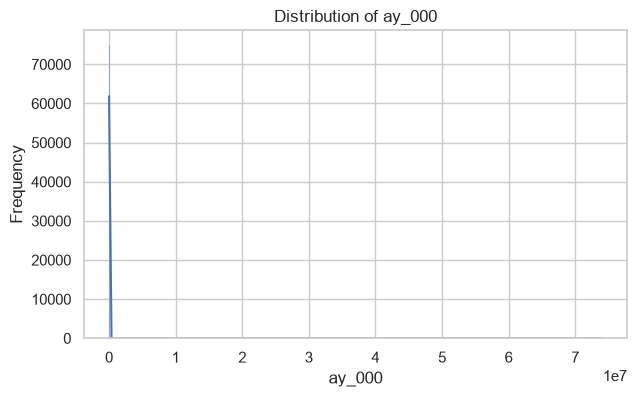

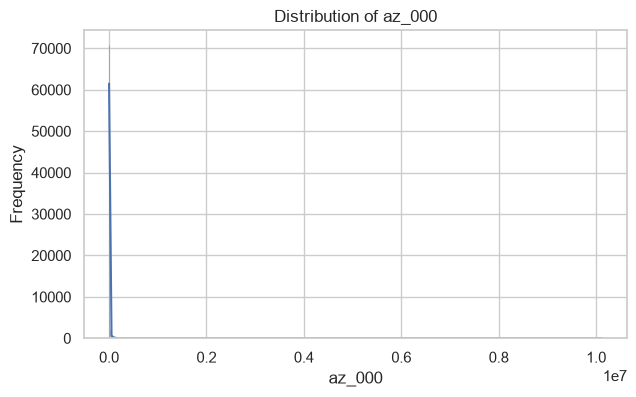

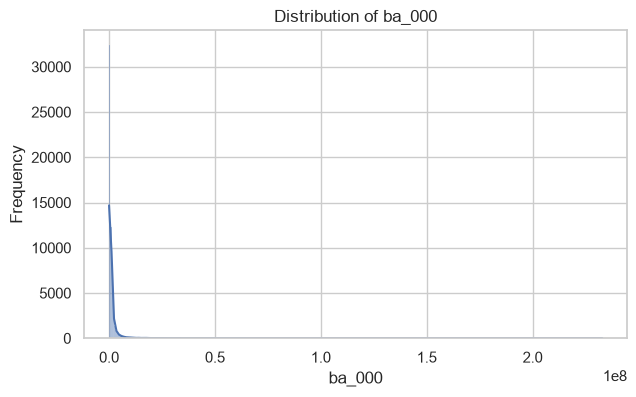

In [9]:
candidate_features = [c for c in ["aa_000", "ag_000", "ay_000", "az_000", "ba_000"] if c in X.columns]
for col in candidate_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(X[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


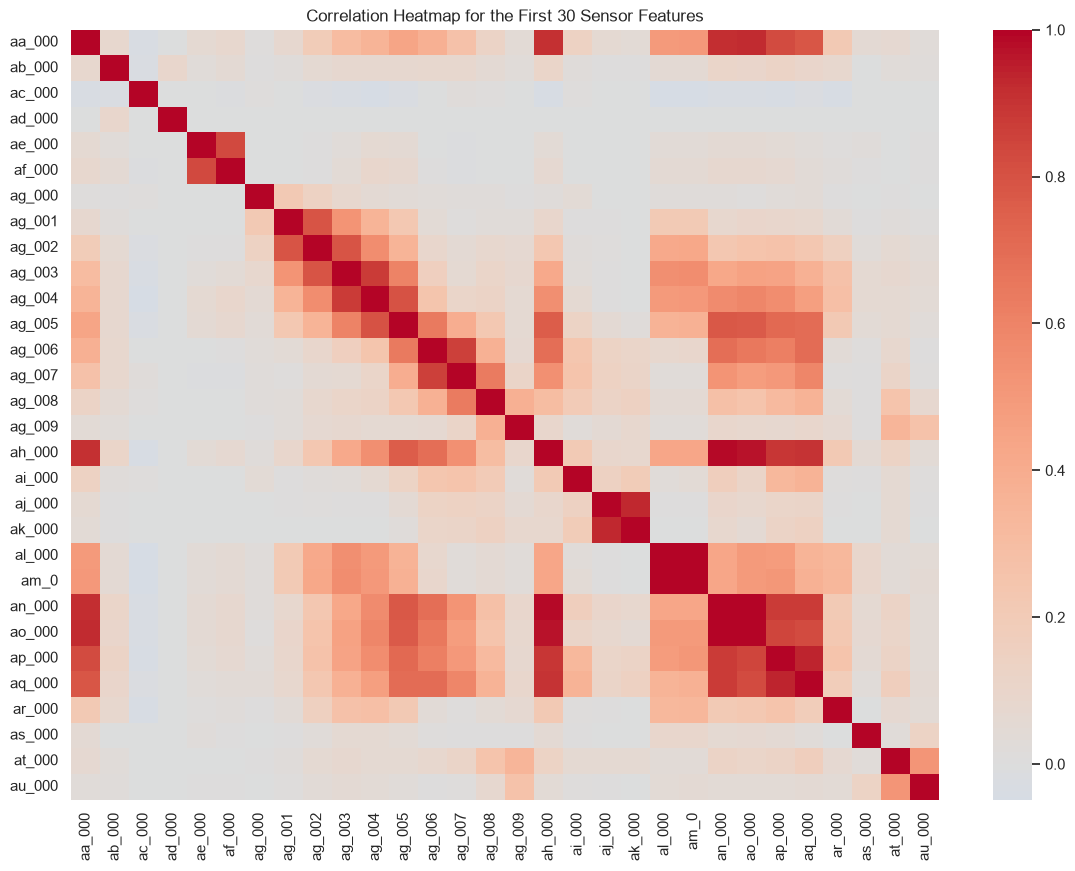

In [10]:
corr = X.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr.iloc[:30, :30], cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for the First 30 Sensor Features")
plt.show()


### EDA Observations

1. The target distribution is highly imbalanced, with far fewer positive failure cases.
2. Several sensor features contain substantial missingness, so median imputation is required.
3. Sensor variables have different scales and ranges; scaling is useful for Logistic Regression.
4. Correlated sensor readings may measure related vehicle behavior, but they are retained because their predictive value is not known before modelling.


## 6. Feature Engineering and Feature Selection

No artificial features are created because the sensor variables are anonymized and their physical meaning is unavailable. All 170 sensor features are retained after cleaning. This avoids deleting a low-variance feature that may still be useful for failure detection.


In [11]:
feature_names = X.columns.tolist()
print("Number of final modelling features:", len(feature_names))
print("Final feature list:")
print(feature_names)


Number of final modelling features: 170
Final feature list:
['aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', '

## 7. Model Building and Training

Three supervised classification models are implemented: Logistic Regression as a linear baseline, Decision Tree as an interpretable nonlinear model, and Random Forest as an ensemble model. Class weights give greater importance to the minority failure class.


In [12]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced", max_iter=2000,
            solver="liblinear", random_state=RANDOM_STATE
        ))
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            class_weight="balanced", max_depth=12,
            min_samples_leaf=5, random_state=RANDOM_STATE
        ))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200, class_weight="balanced_subsample",
            n_jobs=-1, random_state=RANDOM_STATE
        ))
    ])
}


In [13]:
results = []
trained_models = {}

for name, model in models.items():
    print("Training:", name)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities)
    })
    trained_models[name] = model

comparison_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
display(comparison_df.round(4))
comparison_df.to_csv("model_comparison_baseline.csv", index=False)


Training: Logistic Regression
Training: Decision Tree
Training: Random Forest


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
2,Random Forest,0.9918,0.9314,0.5927,0.7244,0.9910,0.8839
0,Logistic Regression,0.9741,0.4048,0.9200,0.5622,0.9751,0.7822
1,Decision Tree,0.9724,0.3847,0.8800,0.5354,0.8873,0.4723


## 8. Cross Validation

Cross-validation estimates how consistently the models perform across multiple stratified training and validation folds. The pipeline ensures that preprocessing is repeated safely inside each fold.


In [14]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}
cv_rows = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_df = pd.DataFrame(cv_rows).sort_values("CV F1", ascending=False)
display(cv_df.round(4))


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
2,Random Forest,0.9907,0.8826,0.5600,0.6852,0.9844
0,Logistic Regression,0.9754,0.4170,0.8991,0.5695,0.9695
1,Decision Tree,0.9731,0.3869,0.8309,0.5279,0.8811


## 9. Hyperparameter Tuning

Randomized search is used for the Random Forest. Recall is selected as the search objective because the project prioritizes detection of actual failures.


In [15]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5]
}

search = RandomizedSearchCV(
    estimator=models["Random Forest"],
    param_distributions=param_grid,
    n_iter=10, scoring="recall", cv=3,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)
print("Best cross-validation recall:", round(search.best_score_, 4))

tuned_model = search.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'model__n_estimators': 300, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 10}
Best cross-validation recall: 0.8873


In [16]:
tuned_predictions = tuned_model.predict(X_test)
tuned_probabilities = tuned_model.predict_proba(X_test)[:, 1]

tuned_metrics = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, tuned_predictions),
    "Precision": precision_score(y_test, tuned_predictions, zero_division=0),
    "Recall": recall_score(y_test, tuned_predictions, zero_division=0),
    "F1-Score": f1_score(y_test, tuned_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, tuned_probabilities),
    "PR-AUC": average_precision_score(y_test, tuned_probabilities)
}])

comparison_final = pd.concat([comparison_df, tuned_metrics], ignore_index=True)
comparison_final = comparison_final.sort_values("F1-Score", ascending=False)
display(comparison_final.round(4))
comparison_final.to_csv("model_comparison_final.csv", index=False)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.9918,0.9314,0.5927,0.7244,0.9910,0.8839
3,Tuned Random Forest,0.9747,0.4114,0.9200,0.5685,0.9900,0.7606
1,Logistic Regression,0.9741,0.4048,0.9200,0.5622,0.9751,0.7822
2,Decision Tree,0.9724,0.3847,0.8800,0.5354,0.8873,0.4723


## 10. Model Evaluation

The following cells provide the detailed evaluation required for the final report.


In [17]:
print(classification_report(
    y_test, tuned_predictions,
    target_names=["No APS Failure", "APS Failure"],
    zero_division=0
))


                precision    recall  f1-score   support

No APS Failure       1.00      0.98      0.99     14925
   APS Failure       0.41      0.92      0.57       275

      accuracy                           0.97     15200
     macro avg       0.70      0.95      0.78     15200
  weighted avg       0.99      0.97      0.98     15200



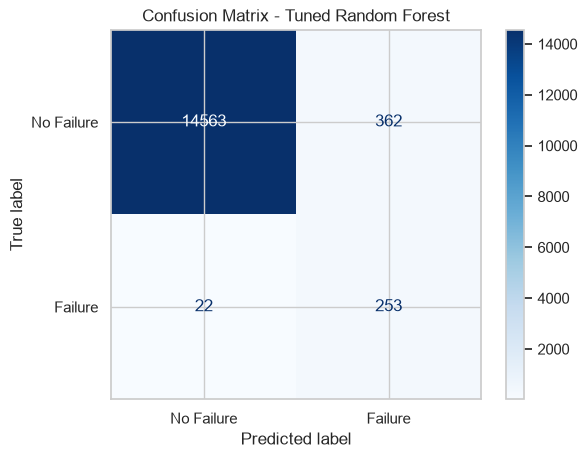

Confusion matrix values [TN, FP; FN, TP]:
[[14563   362]
 [   22   253]]


In [18]:
cm = confusion_matrix(y_test, tuned_predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()
print("Confusion matrix values [TN, FP; FN, TP]:")
print(cm)


<Figure size 800x600 with 0 Axes>

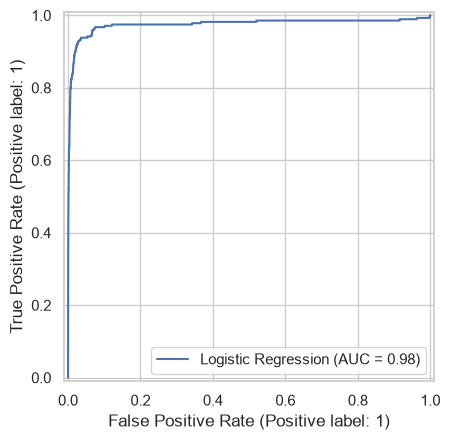

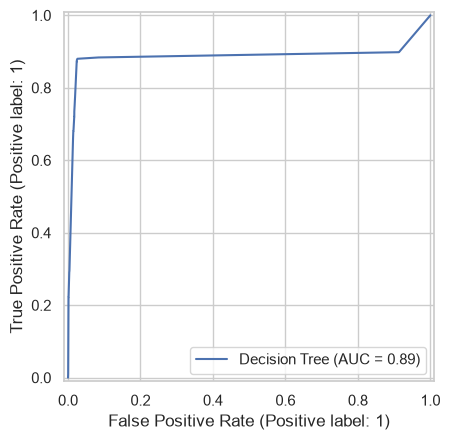

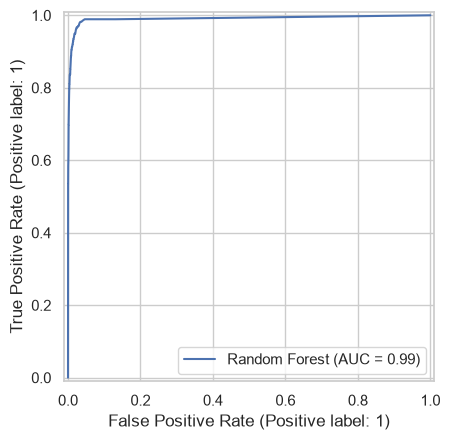

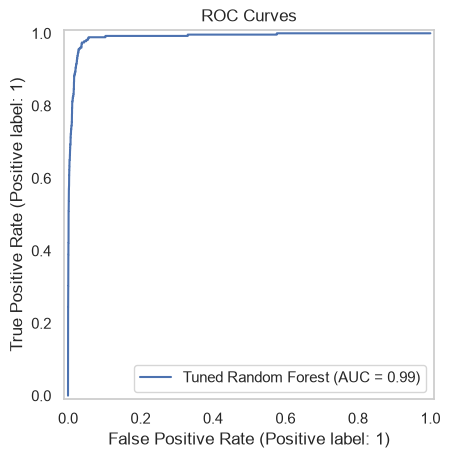

In [19]:
plt.figure(figsize=(8, 6))
for name, model in trained_models.items():
    RocCurveDisplay.from_predictions(
        y_test, model.predict_proba(X_test)[:, 1], name=name
    )
RocCurveDisplay.from_predictions(
    y_test, tuned_probabilities, name="Tuned Random Forest"
)
plt.title("ROC Curves")
plt.grid()
plt.show()


### Results Discussion Prompt

After executing the cells, explain which model had the best recall, F1-score, and ROC-AUC. Discuss the trade-off between detecting more failures and generating more false alarms. Do not select the model using accuracy alone.


## 11. Final Prediction Demonstration

This section demonstrates prediction on records that were not used to fit the final model.


In [20]:
final_model = tuned_model
sample_input = X_test.iloc[[0, 1, 2]]
sample_prediction = final_model.predict(sample_input)
sample_probability = final_model.predict_proba(sample_input)[:, 1]

prediction_output = pd.DataFrame({
    "Predicted_Class": sample_prediction,
    "Failure_Probability": sample_probability
})
prediction_output["Predicted_Label"] = prediction_output["Predicted_Class"].map({
    0: "No APS Failure",
    1: "APS Failure"
})
display(prediction_output)


,Predicted_Class,Failure_Probability,Predicted_Label
0,0,0.007712,No APS Failure
1,0,0.010033,No APS Failure
2,0,0.008251,No APS Failure


In [21]:
joblib.dump(final_model, "final_aps_failure_model.joblib")
print("Final model saved successfully.")


Final model saved successfully.


## 12. Final Conclusion

The completed experiment cleans and analyzes high-dimensional sensor data, trains multiple class-weighted classifiers, tunes the strongest candidate, and evaluates the final model on an untouched test set. The final model should be described as a decision-support tool for prioritizing vehicle inspection, not as a replacement for professional maintenance.

Before submission, confirm that every cell has been executed, the model comparison table contains real values, all plots are visible, and the report uses the same values as this notebook.
